# SAHI with Ultralytics for Sliced Inference

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/obss/sahi/blob/main/demo/inference_for_ultralytics.ipynb)

## 0. Preparation

- Install latest version of SAHI and ultralytics:

In [ ]:
!pip install -U torch sahi ultralytics
!pip install ipywidgets

In [8]:
# import os
# os.getcwd()

- Import required modules:

In [1]:
from IPython.display import Image

from sahi import AutoDetectionModel
from sahi.predict import get_prediction, get_sliced_prediction, predict
from sahi.utils.cv import read_image
from sahi.utils.file import download_from_url

- Download two test images:

In [2]:
download_from_url(
    "https://raw.githubusercontent.com/obss/sahi/main/demo/demo_data/small-vehicles1.jpeg",
    "demo_data/small-vehicles1.jpeg",
)
download_from_url(
    "https://raw.githubusercontent.com/obss/sahi/main/demo/demo_data/terrain2.png", "demo_data/terrain2.png"
)
download_from_url("https://ultralytics.com/images/boats.jpg", "demo_data/obb_test_image.png")

## 1. Standard Inference with an Ultralytics Model

- Instantiate a detection model by defining model weight path and other parameters:

In [9]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path="yolo26n.pt",  # any yolov8/yolov9/yolo11/yolo12/rt-detr/yolo26 det model is supported
    confidence_threshold=0.35,
    device="cuda:0",  # or 'cuda:0' if GPU is available
)

- Perform prediction by feeding the `get_prediction` function with an image path and a DetectionModel instance:

In [10]:
result = get_prediction("demo_data/small-vehicles1.jpeg", detection_model)

- Or perform prediction by feeding the `get_prediction` function with a numpy image and a DetectionModel instance:

In [11]:
result = get_prediction(read_image("demo_data/small-vehicles1.jpeg"), detection_model)

- Visualize predicted bounding boxes and masks over the original image:

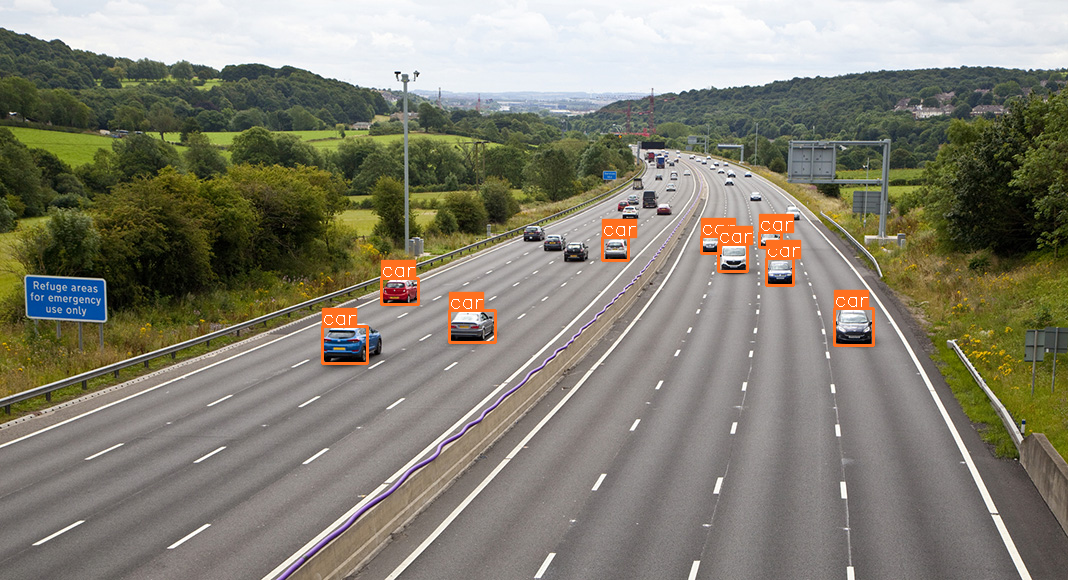

In [12]:
result.export_visuals(export_dir="demo_data/", hide_conf=True)

Image("demo_data/prediction_visual.png")

## 2. Sliced Inference with a YOLOv8/YOLO11/YOLO26 Model

- To perform sliced prediction we need to specify slice parameters. In this example we will perform prediction over slices of 256x256 with an overlap ratio of 0.2:

In [13]:
result = get_sliced_prediction(
    "demo_data/small-vehicles1.jpeg",
    detection_model,
    slice_height=256,
    slice_width=256,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
)

Performing prediction on 15 slices.


- Visualize predicted bounding boxes and masks over the original image:

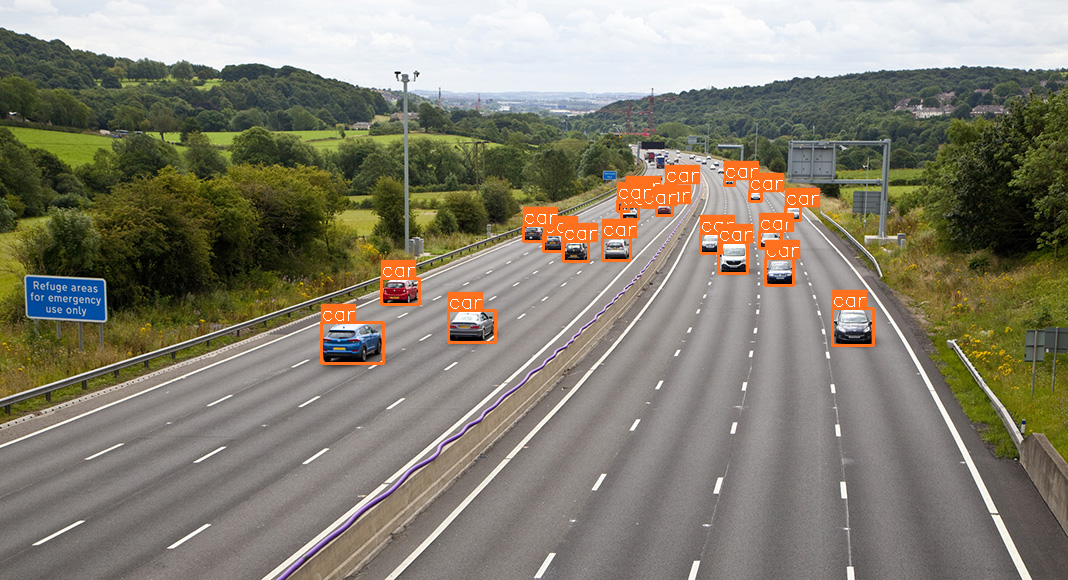

In [14]:
result.export_visuals(export_dir="demo_data/", hide_conf=True)

Image("demo_data/prediction_visual.png")

## 3. Prediction Result

- Predictions are returned as [sahi.prediction.PredictionResult](sahi/prediction.py), you can access the object prediction list as:

In [15]:
object_prediction_list = result.object_prediction_list

In [16]:
object_prediction_list[0]

ObjectPrediction<
    bbox: BoundingBox: <(np.float64(448.2227973937988), np.float64(310.30006408691406), np.float64(495.9568176269531), np.float64(342.88134765625)), w: 47.7340202331543, h: 32.58128356933594>,
    mask: None,
    score: PredictionScore: <value: 0.910740852355957>,
    category: Category: <id: 2, name: car>>

- ObjectPrediction's can be converted to [COCO annotation](https://cocodataset.org/#format-data) format:

In [17]:
result.to_coco_annotations()[:3]

[{'image_id': None,
  'bbox': [448.2227973937988,
   310.30006408691406,
   47.7340202331543,
   32.58128356933594],
  'score': np.float32(0.91074085),
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1555},
 {'image_id': None,
  'bbox': [321.33956146240234,
   322.15140533447266,
   61.971168518066406,
   41.540428161621094],
  'score': np.float32(0.8870753),
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 2574},
 {'image_id': None,
  'bbox': [832.8875637054443,
   308.15055084228516,
   41.06988334655762,
   37.26213836669922],
  'score': np.float32(0.868108),
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1530}]

- ObjectPrediction's can be converted to [COCO prediction](https://github.com/i008/COCO-dataset-explorer) format:

In [18]:
result.to_coco_predictions(image_id=1)[:3]

[{'image_id': 1,
  'bbox': [448.2227973937988,
   310.30006408691406,
   47.7340202331543,
   32.58128356933594],
  'score': np.float32(0.91074085),
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1555},
 {'image_id': 1,
  'bbox': [321.33956146240234,
   322.15140533447266,
   61.971168518066406,
   41.540428161621094],
  'score': np.float32(0.8870753),
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 2574},
 {'image_id': 1,
  'bbox': [832.8875637054443,
   308.15055084228516,
   41.06988334655762,
   37.26213836669922],
  'score': np.float32(0.868108),
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1530}]

- ObjectPrediction's can be converted to [imantics](https://github.com/jsbroks/imantics) annotation format:

In [ ]:
!pip install imantics
result.to_imantics_annotations()[:3]

- ObjectPrediction's can be converted to [fiftyone](https://github.com/voxel51/fiftyone) detection format:

In [ ]:
!pip install fiftyone
result.to_fiftyone_detections()[:3]

## 4. Batch Prediction

- Set model and directory parameters:

In [23]:
model_type = "ultralytics"
model_path = "yolo26n.pt"
model_device = "cuda"  # or 'cuda:0' if GPU is available
model_confidence_threshold = 0.4

slice_height = 256
slice_width = 256
overlap_height_ratio = 0.2
overlap_width_ratio = 0.2

source_image_dir = "demo_data/"

- Perform sliced inference on given folder:

In [24]:
predict(
    model_type=model_type,
    model_path=model_path,
    model_device=model_device,
    model_confidence_threshold=model_confidence_threshold,
    source=source_image_dir,
    slice_height=slice_height,
    slice_width=slice_width,
    overlap_height_ratio=overlap_height_ratio,
    overlap_width_ratio=overlap_width_ratio,
)

There are 3 listed files in folder: demo_data/


Performing inference on images:  33%|███▎      | 1/3 [00:00<00:00,  7.51it/s]

Performing prediction on 20 slices.
Prediction time is: 106.71 ms
Performing prediction on 15 slices.


Performing inference on images: 100%|██████████| 3/3 [00:00<00:00,  9.20it/s]

Prediction time is: 68.49 ms
Performing prediction on 15 slices.
Prediction time is: 67.87 ms
Prediction results are successfully exported to runs/predict/exp3


# 5 Sliced Segmentation

Run the same steps for YOLO11 segmentation model:

In [26]:
detection_model_seg = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path="yolo26n-seg.pt",  # any yolov8/yolov9/yolo11/yolo12/yolo26 seg model is supported
    confidence_threshold=0.3,
    device="cuda:0",  # or 'cuda:0' if GPU is available
)

im = read_image("demo_data/small-vehicles1.jpeg")

- Perform standard segmentation:

In [27]:
result = get_prediction(im, detection_model_seg)

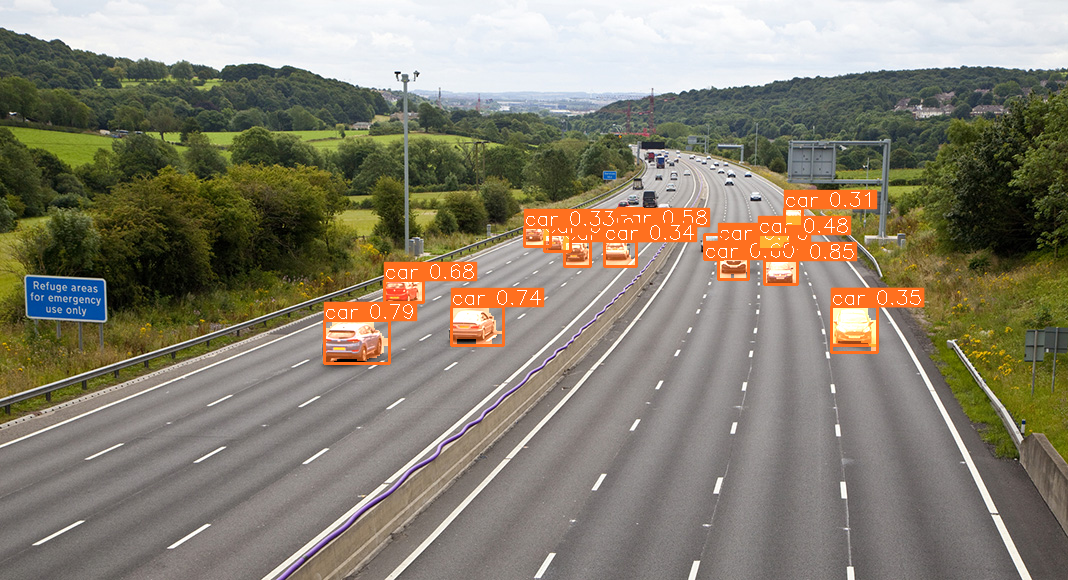

In [28]:
result.export_visuals(export_dir="demo_data/")

Image("demo_data/prediction_visual.png")

- Repeat for sliced segmentation:

In [29]:
result = get_sliced_prediction(
    im, detection_model_seg, slice_height=256, slice_width=256, overlap_height_ratio=0.2, overlap_width_ratio=0.2
)

Performing prediction on 15 slices.


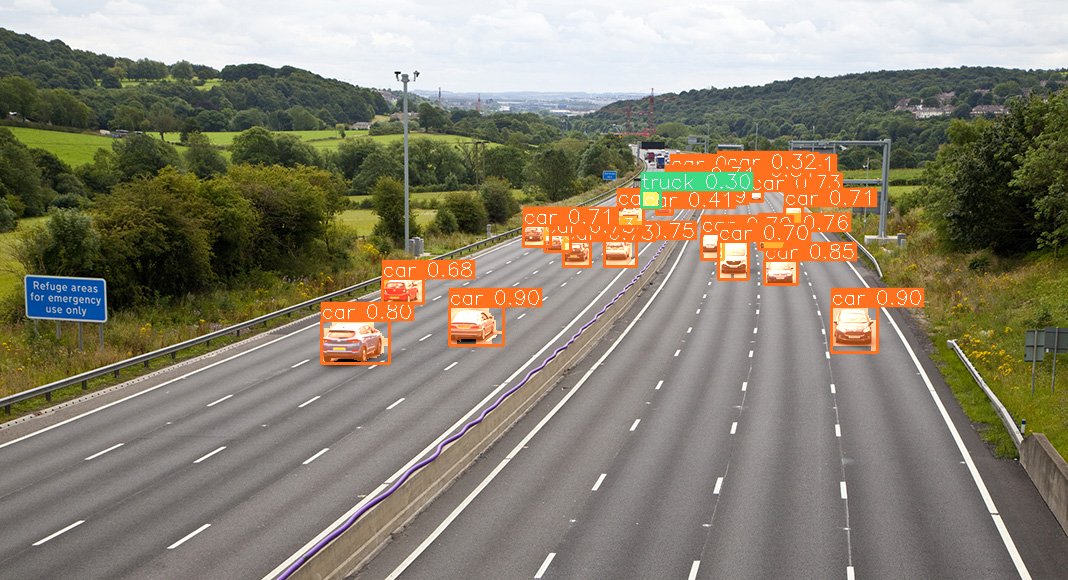

In [30]:
result.export_visuals(export_dir="demo_data/")

Image("demo_data/prediction_visual.png")

Sliced predictions are much better!

- Observe the prediction format:

In [31]:
object_prediction_list = result.object_prediction_list
object_prediction_list[0]

ObjectPrediction<
    bbox: BoundingBox: <(831, 306, 877, 352), w: 46, h: 46>,
    mask: <sahi.annotation.Mask object at 0xf47ccc113230>,
    score: PredictionScore: <value: 0.9009754657745361>,
    category: Category: <id: 2, name: car>>

In [32]:
object_prediction_list[0].mask.segmentation

[[869,
  345,
  870,
  345,
  871,
  346,
  871,
  352,
  877,
  352,
  877,
  345,
  877,
  320,
  871,
  320,
  870,
  319,
  870,
  318,
  869,
  318,
  868,
  317,
  868,
  315,
  867,
  314,
  867,
  306,
  831,
  306,
  831,
  342,
  831,
  345]]

In [33]:
predict(
    model_type=model_type,
    model_path=model_path,
    model_device=model_device,
    model_confidence_threshold=model_confidence_threshold,
    source=source_image_dir,
    slice_height=slice_height,
    slice_width=slice_width,
    overlap_height_ratio=overlap_height_ratio,
    overlap_width_ratio=overlap_width_ratio,
)

There are 3 listed files in folder: demo_data/


Performing inference on images:  33%|███▎      | 1/3 [00:00<00:00,  7.68it/s]

Performing prediction on 20 slices.
Prediction time is: 103.91 ms
Performing prediction on 15 slices.


Performing inference on images: 100%|██████████| 3/3 [00:00<00:00,  9.36it/s]

Prediction time is: 67.93 ms
Performing prediction on 15 slices.
Prediction time is: 67.32 ms
Prediction results are successfully exported to runs/predict/exp4


# 7 Sliced OBB Prediction


In [37]:
detection_model_obb = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path="yolo26n-obb.pt",  # any yolov8/yolov9/yolo11/yolo12 obb model is supported
    confidence_threshold=0.3,
    device="cuda:0",  # or 'cuda:0' if GPU is available
)

im = read_image("demo_data/obb_test_image.png")

In [38]:
result = get_sliced_prediction(
    im,
    detection_model_obb,
    slice_height=512,
    slice_width=512,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
    # perform_standard_pred = False
)

Performing prediction on 15 slices.


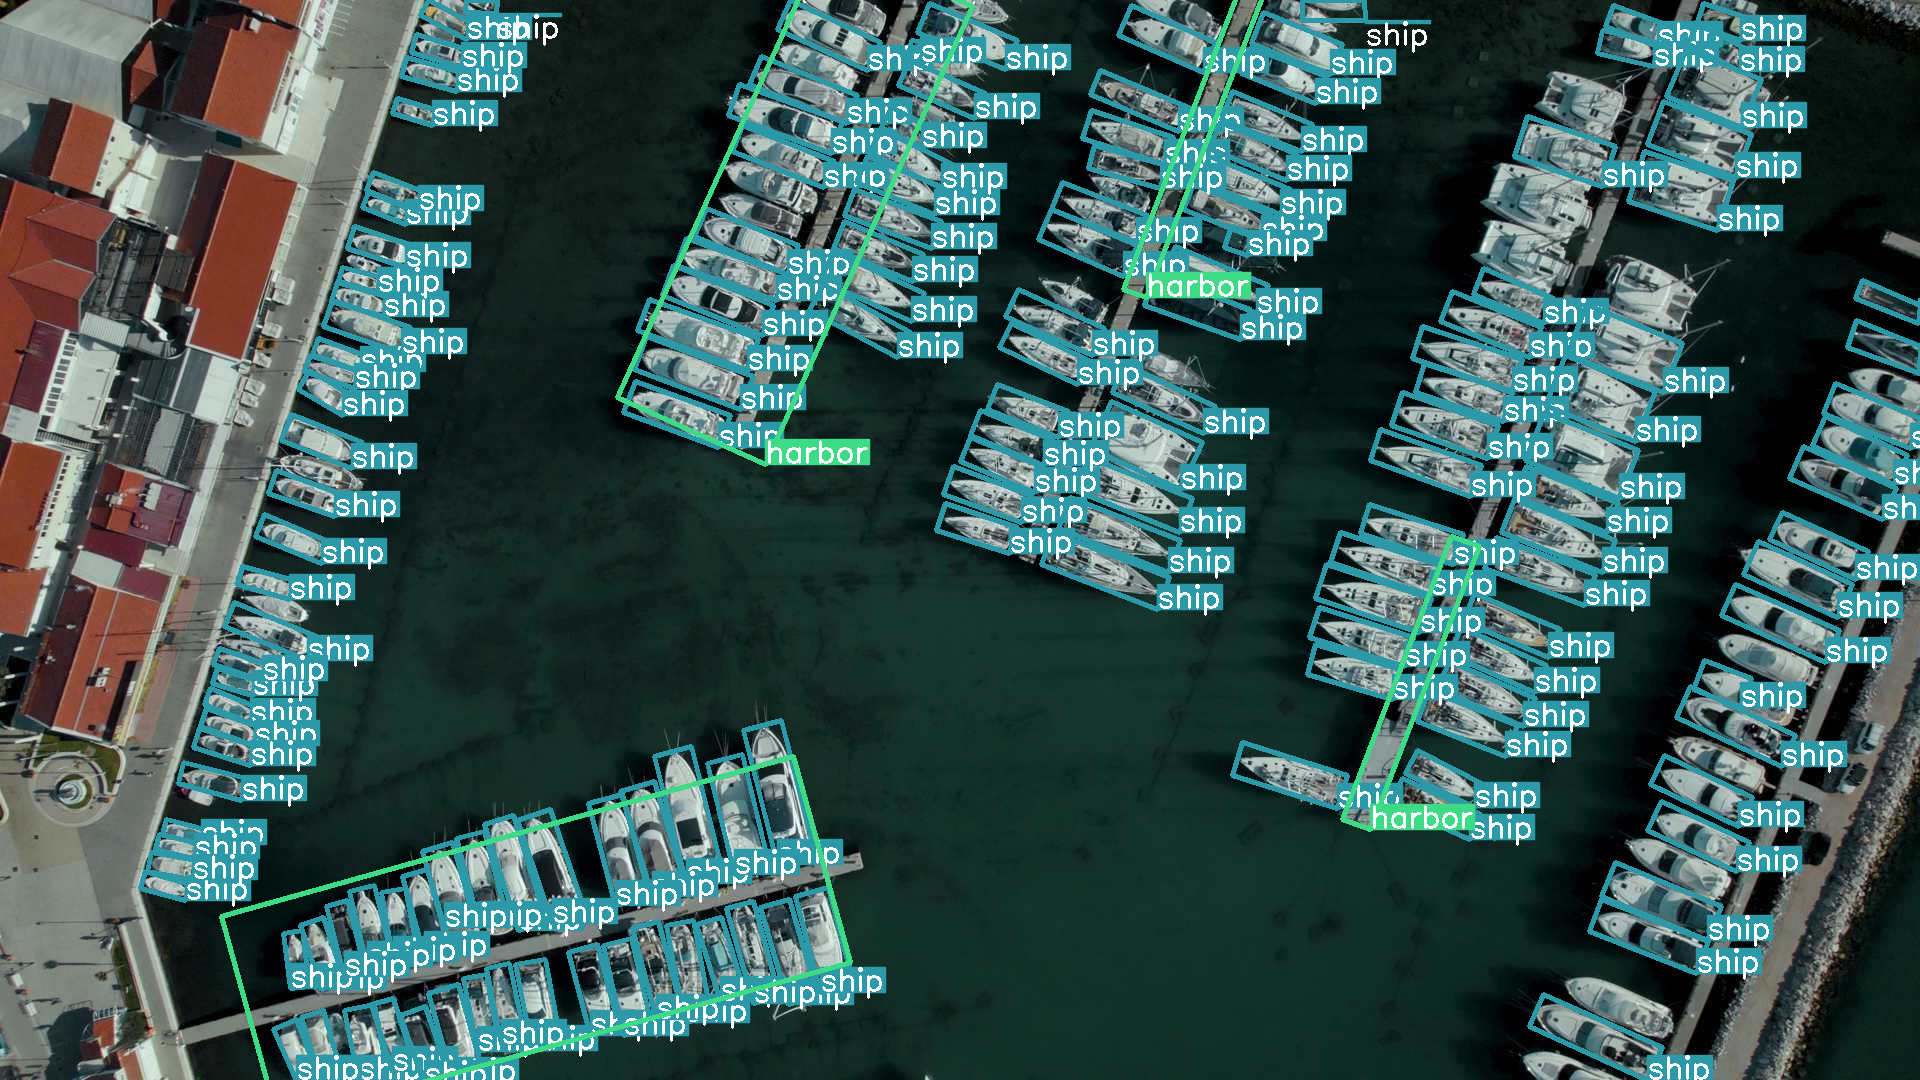

In [40]:
result.export_visuals(export_dir="demo_data/", text_size=1, rect_th=3, hide_conf=True)

Image("demo_data/prediction_visual.png", width=800)